# Étape 2 - EDA (Exploratory Data Analysis)

In [5]:
# Bibliothèques

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

## Chargement et setup

In [14]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('../data/processed/prix_alimentaires_nettoyes.csv')
df['date'] = pd.to_datetime(df['date'])

print(df.shape)
print(df.describe())
df.head()

(73064, 21)
                             date     market_id      latitude     longitude  \
count                       73064  73064.000000  73064.000000  73064.000000   
mean   2022-01-15 00:41:30.397459   4071.437917      7.288011     12.625937   
min           2005-01-15 00:00:00   1578.000000      3.860000      9.170000   
25%           2021-03-15 00:00:00   2255.000000      4.600000     10.280000   
50%           2022-12-15 00:00:00   2613.000000      6.510000     13.580000   
75%           2024-04-15 00:00:00   5272.000000     10.110000     14.330000   
max           2026-07-15 00:00:00   8559.000000     12.390000     15.450000   
std                           NaN   2194.391647      2.722954      2.092774   

       commodity_id          price      usdprice  taux_implicite  \
count  73064.000000   73064.000000  73064.000000    73064.000000   
mean     229.061699    5573.292093      9.787783      592.638297   
min       52.000000      60.910000      0.097000      408.547170   
25% 

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,...,priceflag,pricetype,currency,price,usdprice,taux_implicite,annee,quantite,unite_base,price_per_unit
0,2005-01-15,Centre,Mfoundi,Yaoundé-Mfoundi,2613,3.86,11.52,cereals and tubers,Maize (white),67,...,actual,Retail,XAF,147.78,0.30,492.600000,2005,1.0,KG,147.78
1,2005-01-15,Centre,Mfoundi,Yaoundé-Mfoundi,2613,3.86,11.52,cereals and tubers,Maize (yellow),136,...,actual,Retail,XAF,147.78,0.30,492.600000,2005,1.0,KG,147.78
2,2005-01-15,Littoral,Wouri,Douala-Congo,2579,4.04,9.70,cereals and tubers,Maize (white),67,...,actual,Retail,XAF,183.64,0.37,496.324324,2005,1.0,KG,183.64
3,2005-01-15,Littoral,Wouri,Douala-Congo,2579,4.04,9.70,cereals and tubers,Maize (yellow),136,...,actual,Retail,XAF,183.64,0.37,496.324324,2005,1.0,KG,183.64
4,2005-01-15,Nord,Bénoué,Garoua,1593,9.30,13.40,cereals and tubers,Maize (white),67,...,actual,Retail,XAF,127.53,0.25,510.120000,2005,1.0,KG,127.53


## Tendance générale — prix moyen normalisé dans le temps (tous produits confondus)

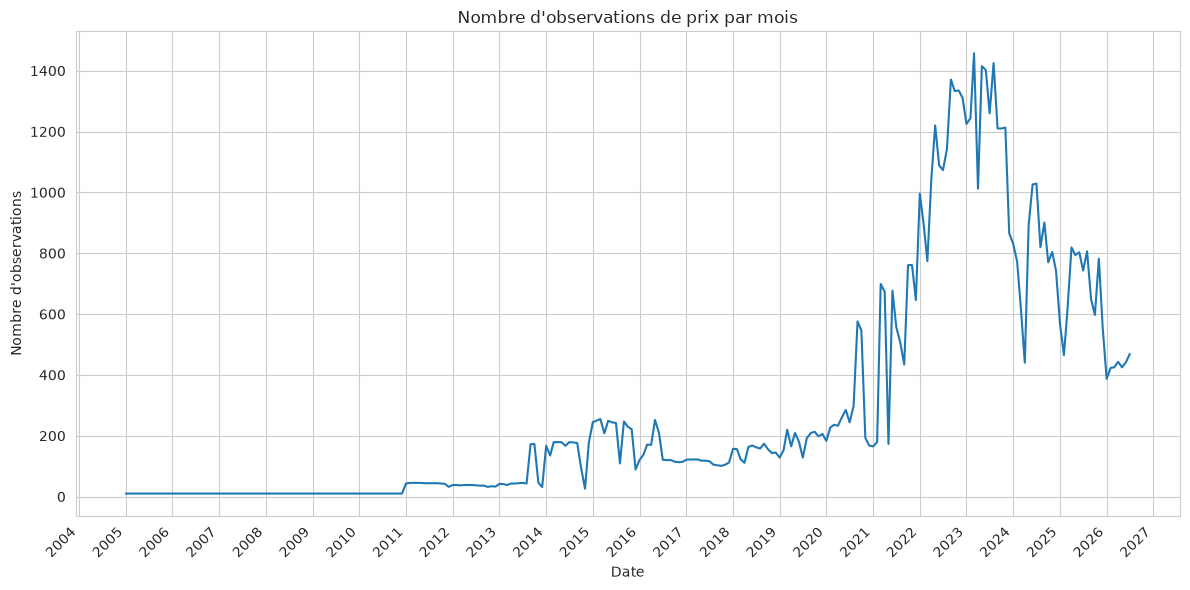

In [18]:
fig, ax = plt.subplots()

ax.plot(obs_par_mois.index, obs_par_mois.values)

ax.set_title("Nombre d'observations de prix par mois")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre d'observations")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
print("Produits présents :")
print(df['commodity'].unique())
print(df['commodity'].value_counts())

Produits présents :
<ArrowStringArray>
[                'Maize (white)',                'Maize (yellow)',
                 'Beans (niebe)',                 'Sorghum (red)',
               'Sorghum (white)',          'Groundnuts (shelled)',
                        'Onions',                  'Rice (local)',
                 'Peas (yellow)',                        'Sesame',
            'Cassava (cossette)',                      'Soybeans',
               'Cassava (fresh)',              'Cocoyam (macabo)',
   'Rice (long grain, imported)',                   'Wheat flour',
        'Fish (mackerel, fresh)',                   'Meat (beef)',
                    'Oil (palm)',                       'Bananas',
                     'Plantains',                 'Cowpeas (Red)',
        'Groundnuts (unshelled)',                   'Beans (red)',
                      'Potatoes',                          'Rice',
                          'Taro',                    'Fish (dry)',
                'Meat (

## Grille pour voir tous les produits d'un coup (ordonnés par nombre d'observations)

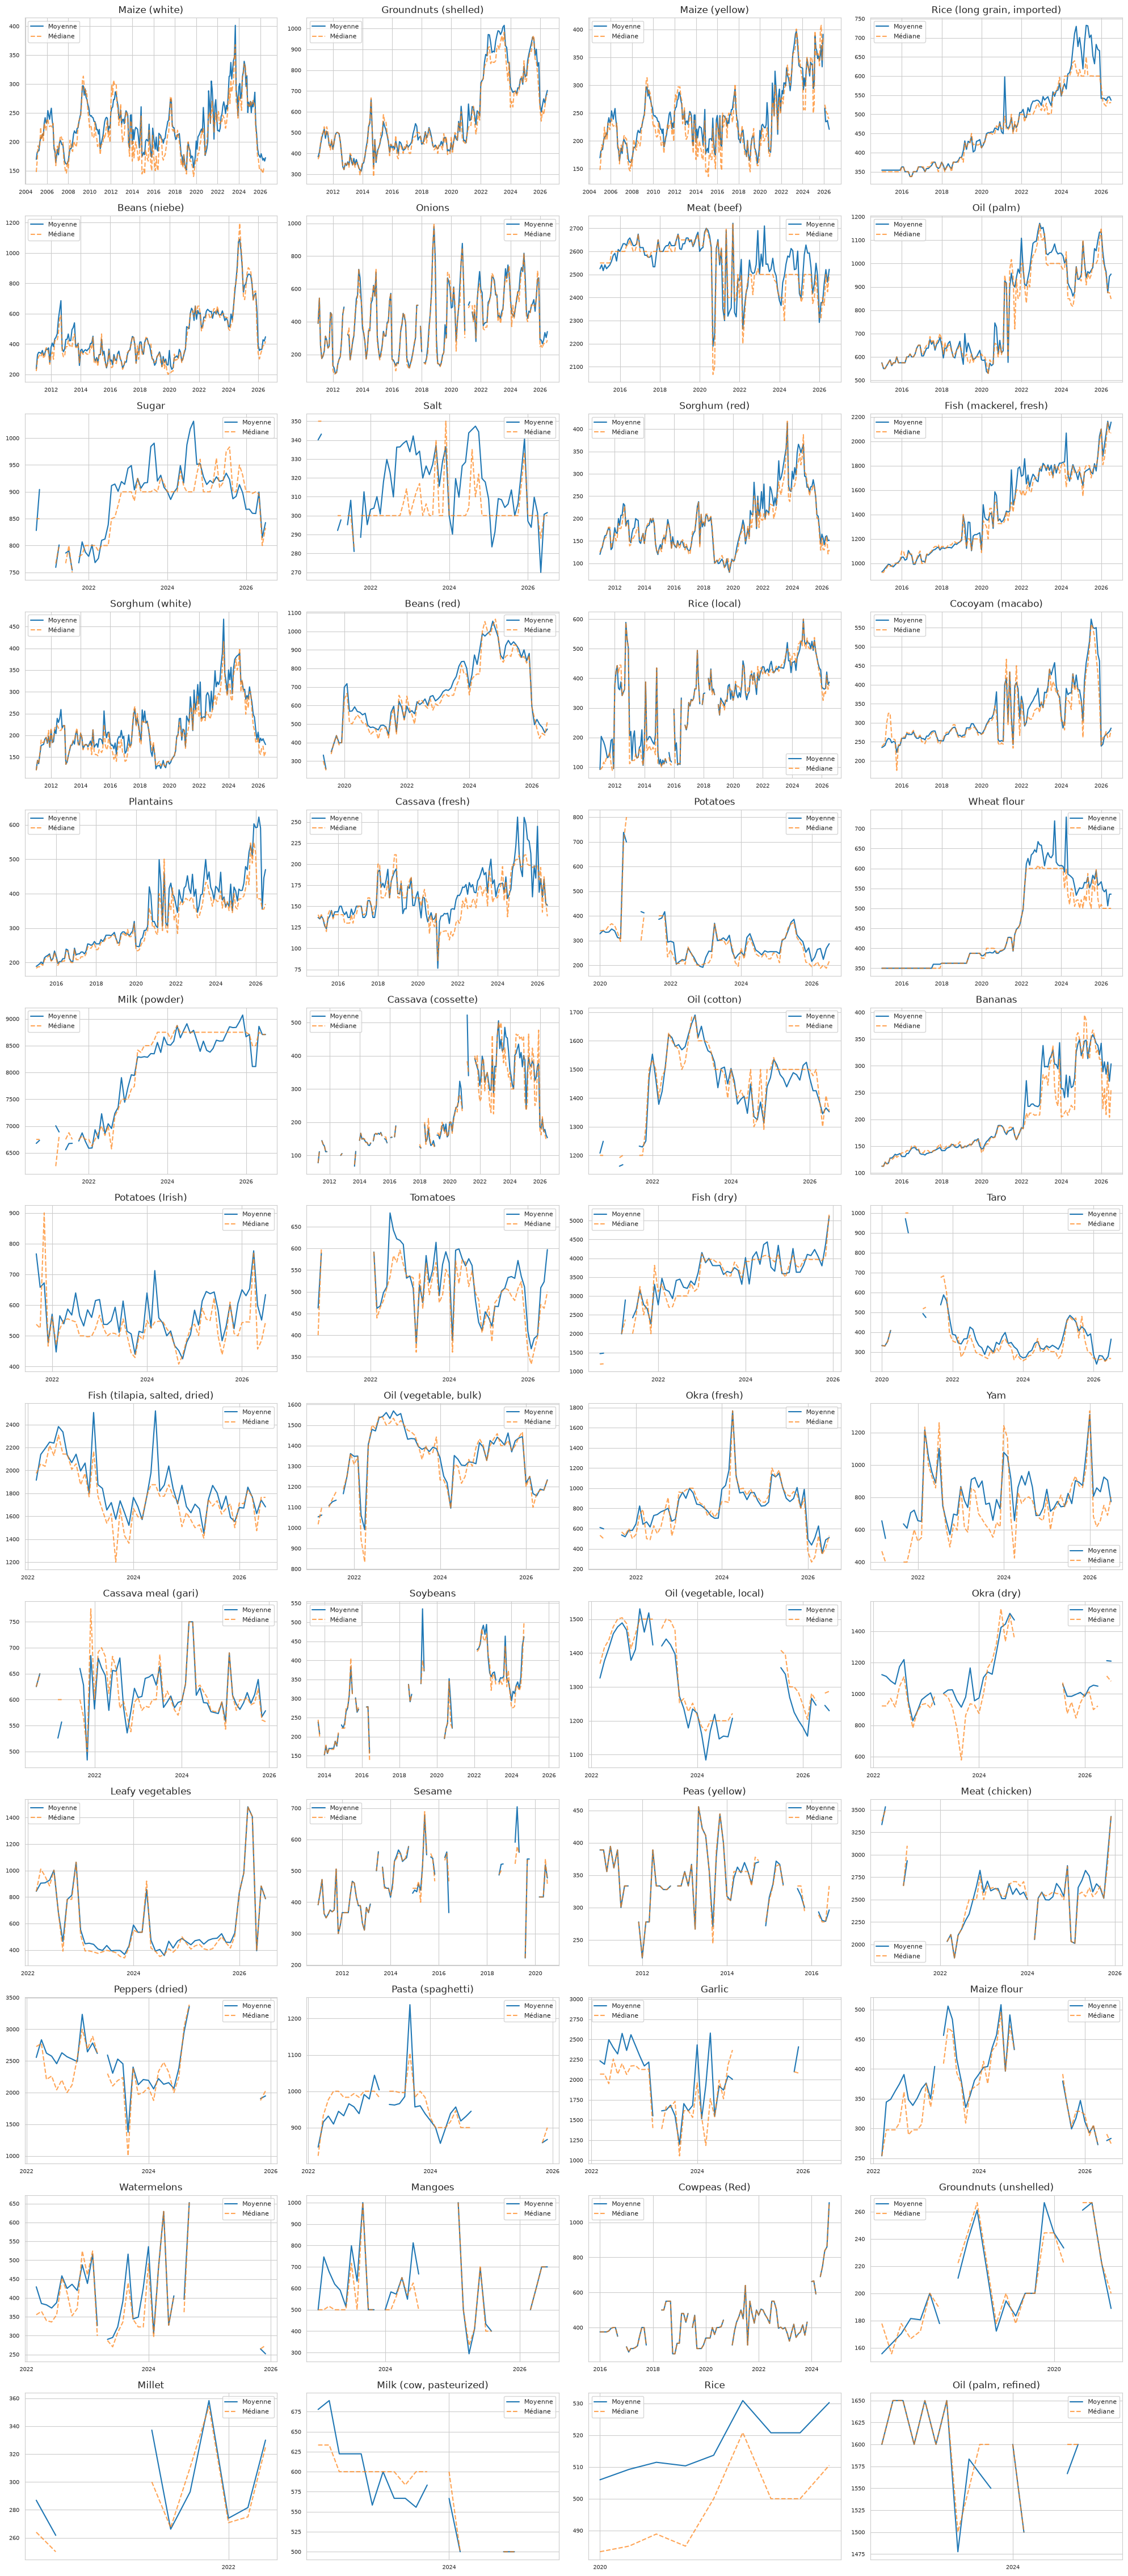

In [26]:
produits_ordonnes = df['commodity'].value_counts().index.tolist()

n = len(produits_ordonnes)
n_cols = 4
n_rows = -(-n // n_cols)  # arrondi supérieur

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, commodity in enumerate(produits_ordonnes):
    plot_prix_produit(df, commodity, ax=axes[i])
    axes[i].tick_params(labelsize=7)
    axes[i].set_ylabel('')

# Cacher les subplots vides restants
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/tous_les_produits.png', dpi=150)
plt.show()

## Identifier les produits bien couverts

In [27]:
# Pour chaque produit : nombre de mois avec au moins 1 observation, sur la période récente stable (2019+)
df_recent = df[df['date'] >= '2019-01-01']

couverture = df_recent.groupby('commodity').apply(
    lambda g: g.set_index('date').resample('MS').size().gt(0).mean()
).sort_values(ascending=False)

print("Taux de couverture mensuelle depuis 2019 (1.0 = tous les mois ont au moins 1 observation) :")
print(couverture.head(20))

Taux de couverture mensuelle depuis 2019 (1.0 = tous les mois ont au moins 1 observation) :
commodity
Bananas                          1.000000
Beans (niebe)                    1.000000
Cassava (fresh)                  1.000000
Leafy vegetables                 1.000000
Cocoyam (macabo)                 1.000000
Fish (mackerel, fresh)           1.000000
Fish (tilapia, salted, dried)    1.000000
Groundnuts (shelled)             1.000000
Maize (white)                    1.000000
Wheat flour                      1.000000
Sorghum (white)                  1.000000
Potatoes (Irish)                 1.000000
Rice                             1.000000
Rice (local)                     1.000000
Rice (long grain, imported)      1.000000
Sorghum (red)                    1.000000
Plantains                        1.000000
Oil (palm)                       1.000000
Meat (beef)                      1.000000
Maize (yellow)                   0.989011
dtype: float64


## Évolution du prix pour UN produit précis (plus fiable qu'une moyenne globale)

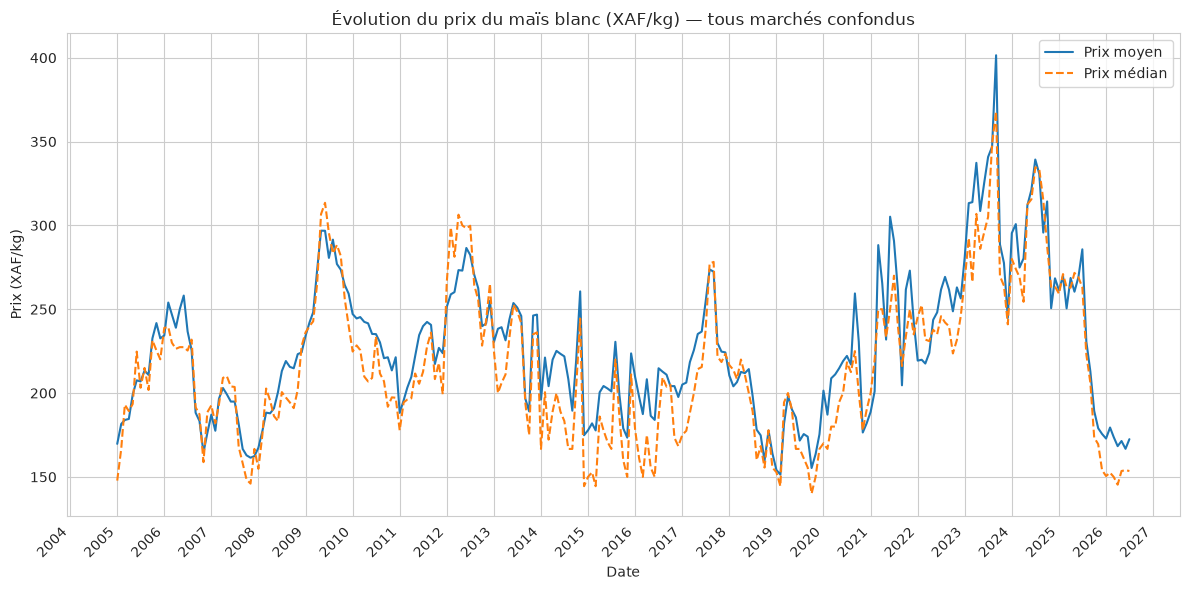

In [ ]:
# Pour le maïs blanc

fig, ax = plt.subplots()

ax.plot(prix_mensuel_maize.index, prix_mensuel_maize['mean'], label='Prix moyen')
ax.plot(prix_mensuel_maize.index, prix_mensuel_maize['median'], label='Prix médian', linestyle='--')

ax.set_title("Évolution du prix du maïs blanc (XAF/kg) — tous marchés confondus")
ax.set_xlabel("Date")
ax.set_ylabel("Prix (XAF/kg)")
ax.legend()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate(rotation=45)

plt.tight_layout()
plt.show()

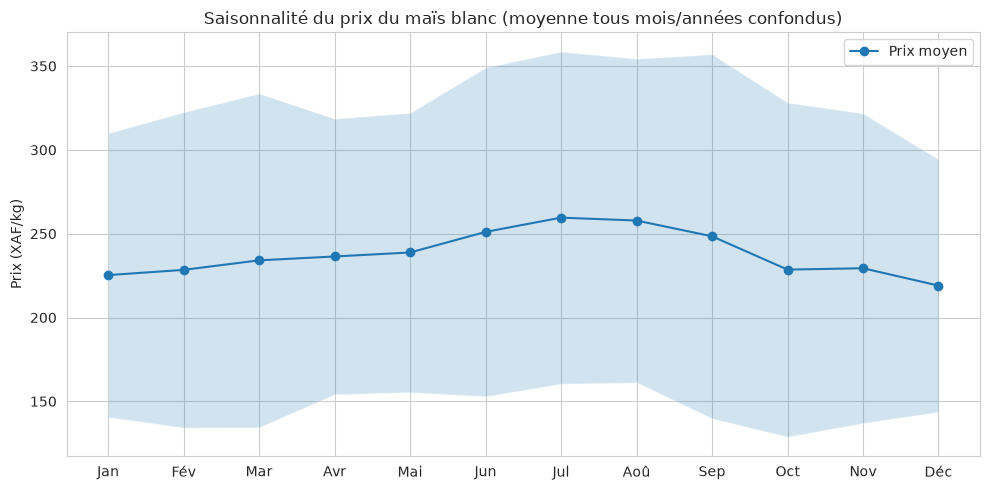

In [28]:
# Saisonnalité — sur le maïs blanc d'abord

maize = df[df['commodity'] == 'Maize (white)'].copy()
maize['mois'] = maize['date'].dt.month

saison = maize.groupby('mois')['price_per_unit'].agg(['mean', 'median', 'std'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(saison.index, saison['mean'], marker='o', label='Prix moyen')
ax.fill_between(saison.index, saison['mean'] - saison['std'], saison['mean'] + saison['std'], alpha=0.2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'])
ax.set_title("Saisonnalité du prix du maïs blanc (moyenne tous mois/années confondus)")
ax.set_ylabel("Prix (XAF/kg)")
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# Fonction réutilisable (pour un produit à la fois)

def plot_prix_produit(df, commodity, ax=None):
    """Trace l'évolution du prix moyen/médian mensuel pour un produit donné."""
    sous_df = df[df['commodity'] == commodity]
    prix_mensuel = (
        sous_df.set_index('date')
        .resample('MS')['price_per_unit']
        .agg(['mean', 'median'])
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(prix_mensuel.index, prix_mensuel['mean'], label='Moyenne')
    ax.plot(prix_mensuel.index, prix_mensuel['median'], label='Médiane', linestyle='--', alpha=0.7)
    ax.set_title(commodity)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(fontsize=8)
    return ax

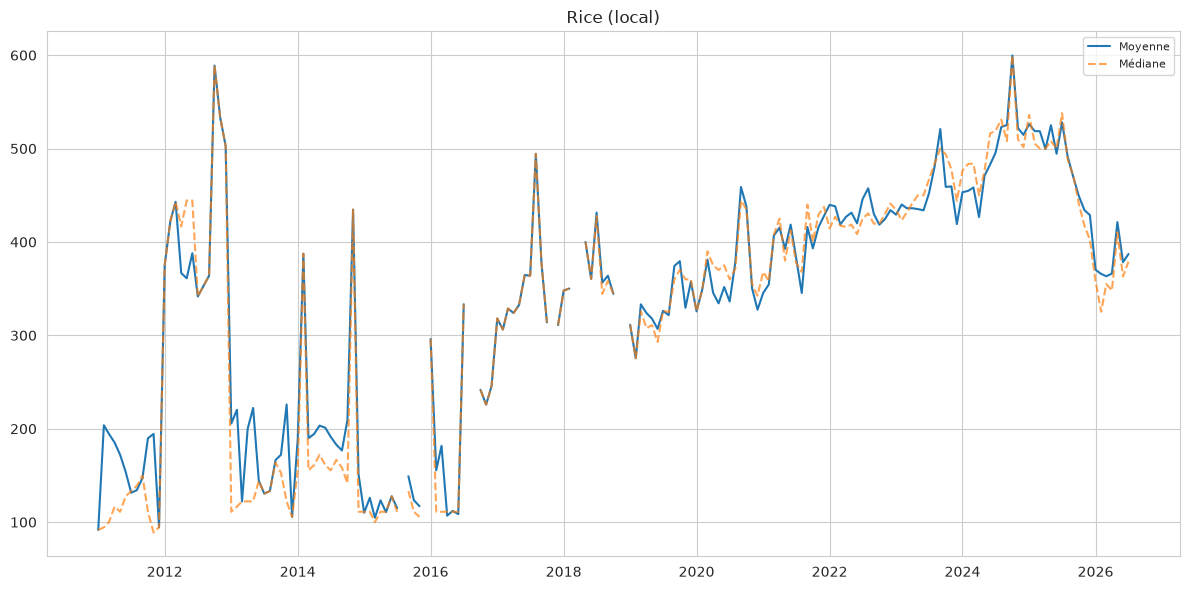

In [ ]:
# Utilisation pour le riz local

fig, ax = plt.subplots(figsize=(12, 6))
plot_prix_produit(df, 'Rice (local)', ax=ax)
plt.tight_layout()
plt.show()

## Comparons maintenant les 6 produits

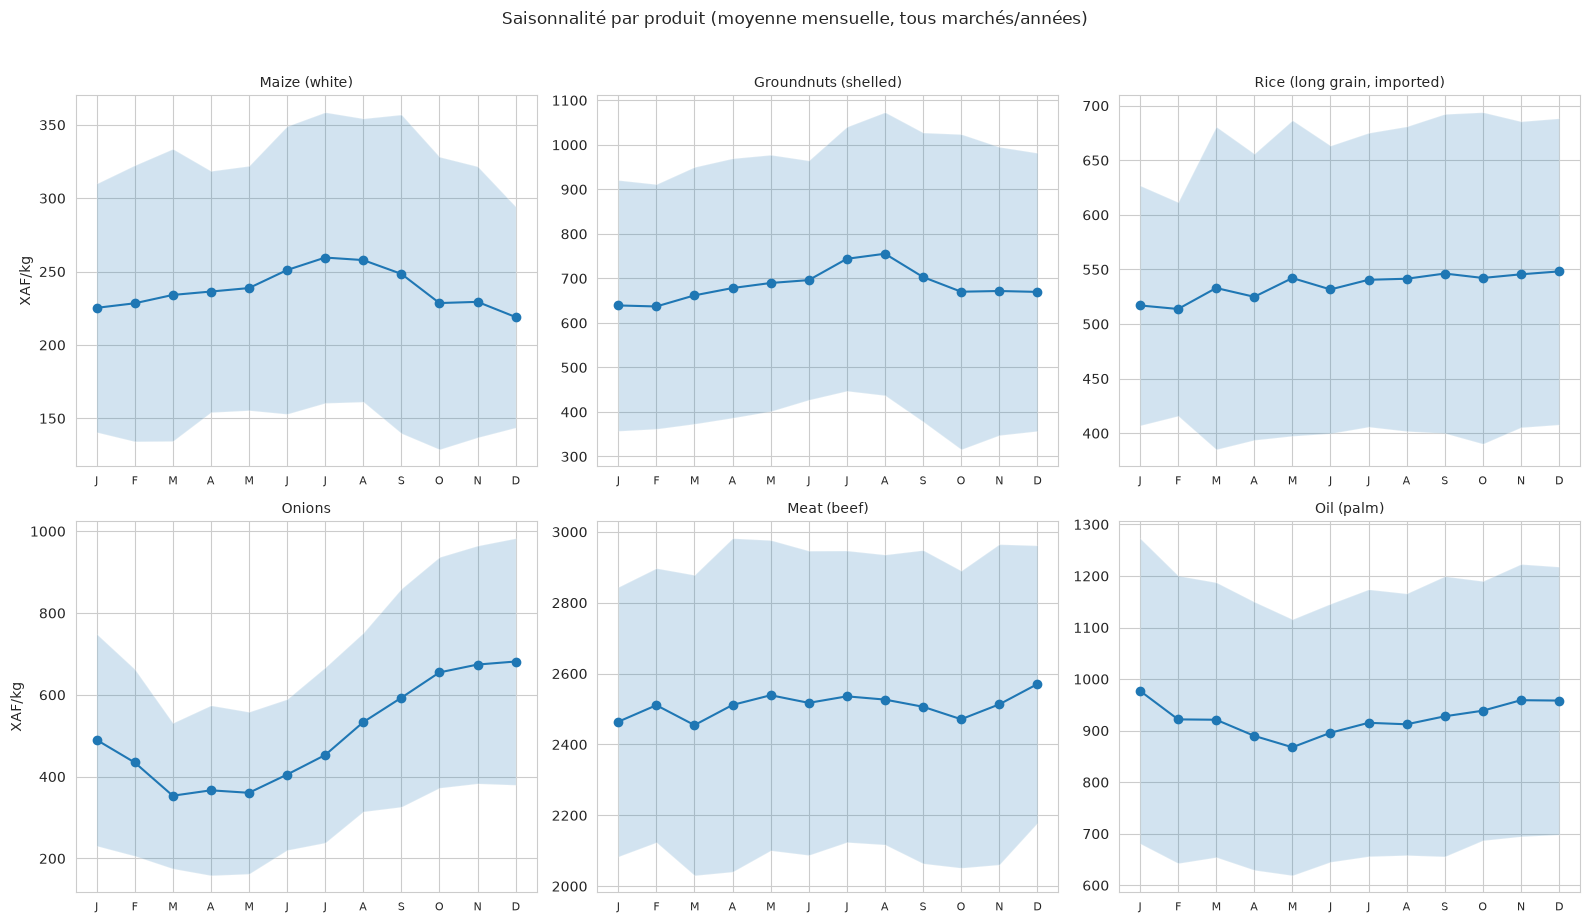

In [29]:
produits_cles = [
    'Maize (white)',
    'Groundnuts (shelled)',
    'Rice (long grain, imported)',
    'Onions',
    'Meat (beef)',
    'Oil (palm)'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, produit in enumerate(produits_cles):
    sous_df = df[df['commodity'] == produit].copy()
    sous_df['mois'] = sous_df['date'].dt.month
    saison = sous_df.groupby('mois')['price_per_unit'].agg(['mean', 'std'])

    ax = axes[i]
    ax.plot(saison.index, saison['mean'], marker='o', color='C0')
    ax.fill_between(saison.index, saison['mean'] - saison['std'], saison['mean'] + saison['std'], alpha=0.2)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=8)
    ax.set_title(produit, fontsize=10)
    ax.set_ylabel('XAF/kg' if i % 3 == 0 else '')

plt.suptitle("Saisonnalité par produit (moyenne mensuelle, tous marchés/années)", y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/saisonnalite_produits_cles.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Pour comparer les amplitudes de façon plus rigoureuse (utile pour repérer quel produit est le plus/moins saisonnier)

resultats = []
for produit in produits_cles:
    sous_df = df[df['commodity'] == produit].copy()
    sous_df['mois'] = sous_df['date'].dt.month
    saison = sous_df.groupby('mois')['price_per_unit'].mean()
    amplitude_pct = (saison.max() - saison.min()) / saison.mean() * 100
    resultats.append({'produit': produit, 'amplitude_saisonniere_%': round(amplitude_pct, 1)})

pd.DataFrame(resultats).sort_values('amplitude_saisonniere_%', ascending=False)

,produit,amplitude_saisonniere_%
3,Onions,65.6
1,Groundnuts (shelled),17.3
0,Maize (white),17.0
5,Oil (palm),11.9
2,"Rice (long grain, imported)",6.4
4,Meat (beef),4.6


# Comparaison régionale

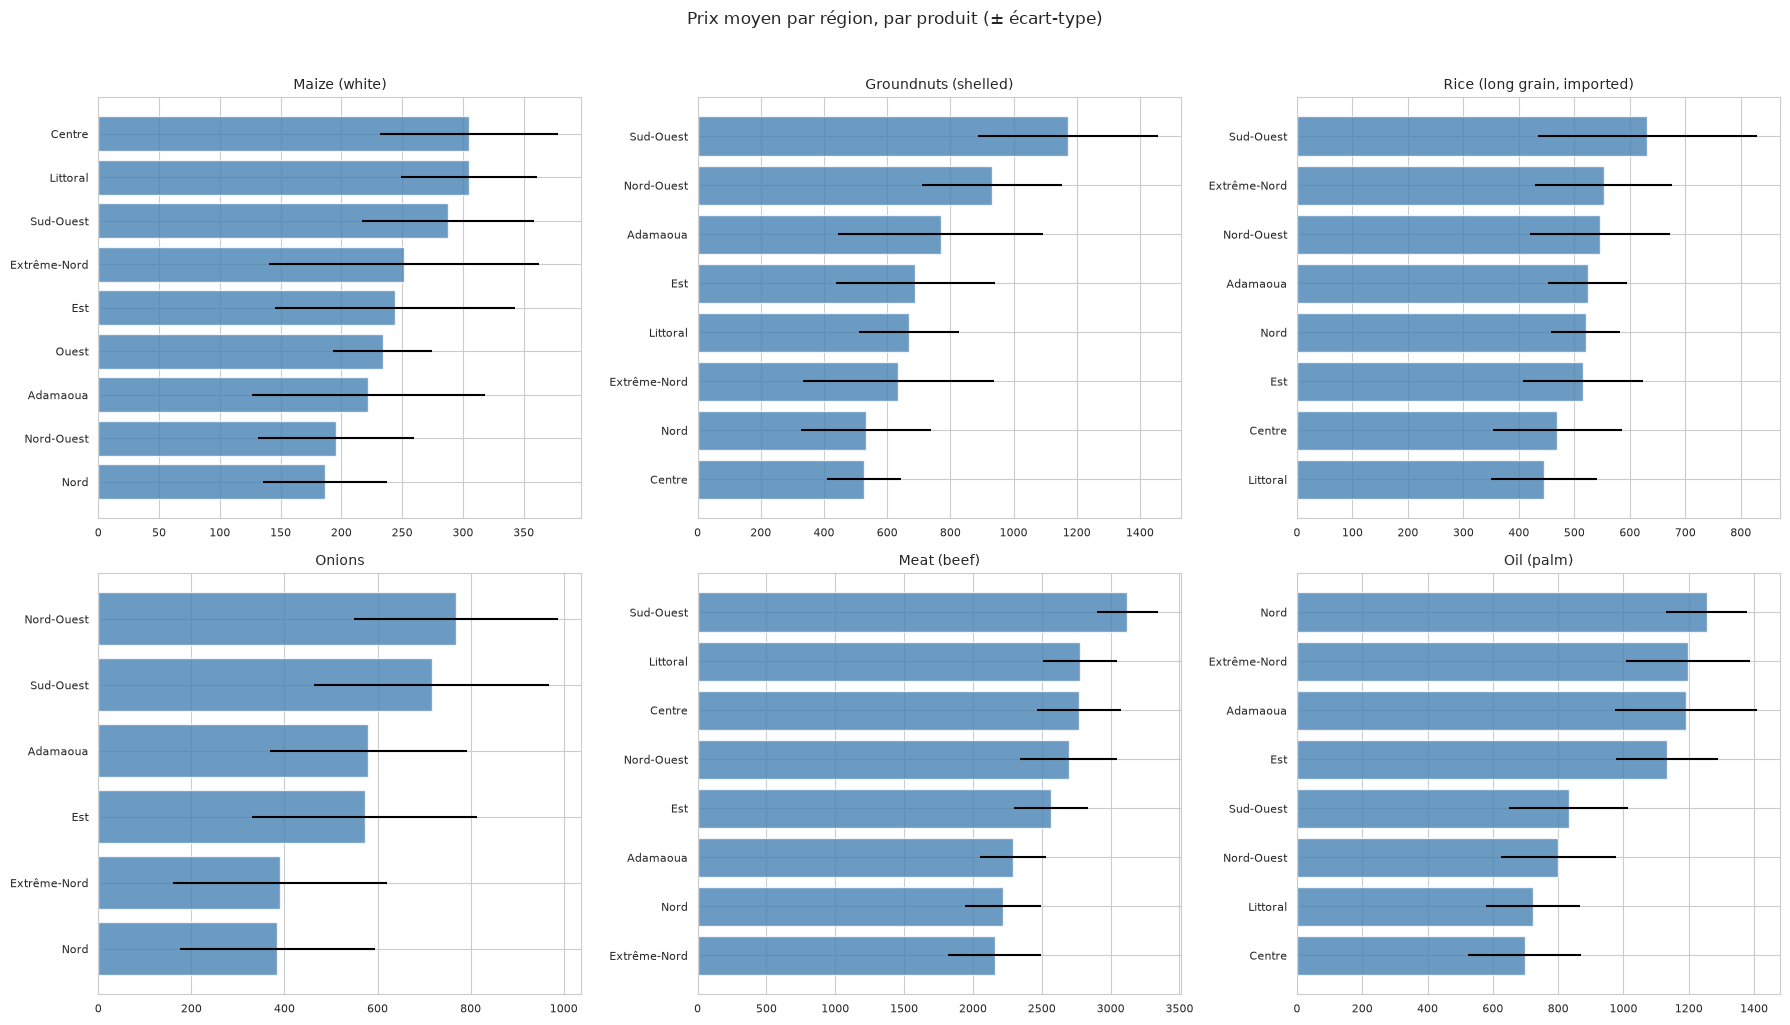

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, produit in enumerate(produits_cles):
    stats = resultats_regionaux[produit].sort_values('mean')
    ax = axes[i]
    ax.barh(stats.index, stats['mean'], xerr=stats['std'], color='steelblue', alpha=0.8)
    ax.set_title(produit, fontsize=10)
    ax.tick_params(labelsize=8)

plt.suptitle("Prix moyen par région, par produit (± écart-type)", y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/prix_regional_tous_produits.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
produits_cles = [
    'Maize (white)',
    'Groundnuts (shelled)',
    'Rice (long grain, imported)',
    'Onions',
    'Meat (beef)',
    'Oil (palm)'
]

resultats_regionaux = {}

for produit in produits_cles:
    sous_df = df[df['commodity'] == produit]
    stats = sous_df.groupby('admin1')['price_per_unit'].agg(['mean', 'std', 'count'])
    stats['coef_variation_%'] = (stats['std'] / stats['mean'] * 100).round(1)
    resultats_regionaux[produit] = stats.round(1)

# Affichage produit par produit
for produit, stats in resultats_regionaux.items():
    print(f"\n{'='*50}\n{produit}\n{'='*50}")
    print(stats.sort_values('mean', ascending=False))


Maize (white)
               mean    std  count  coef_variation_%
admin1                                             
Centre        305.2   73.3    298              24.0
Littoral      305.1   56.0    295              18.4
Sud-Ouest     287.8   70.7    260              24.6
Extrême-Nord  251.3  111.1   1598              44.2
Est           243.8   98.7    344              40.5
Ouest         233.9   40.7    165              17.4
Adamaoua      222.0   95.8    401              43.2
Nord-Ouest    195.6   64.3    624              32.9
Nord          186.5   50.8    745              27.3

Groundnuts (shelled)
                mean    std  count  coef_variation_%
admin1                                              
Sud-Ouest     1172.0  284.1    284              24.2
Nord-Ouest     931.6  221.1    167              23.7
Adamaoua       768.9  323.6    493              42.1
Est            689.3  252.1    657              36.6
Littoral       669.1  159.2    344              23.8
Extrême-Nord   635.2

In [35]:
# Synthétiser le coefficient de variation par région, tous produits confondus

synthese_cv = pd.DataFrame({
    produit: resultats_regionaux[produit]['coef_variation_%']
    for produit in produits_cles
})

synthese_cv['moyenne_tous_produits'] = synthese_cv.mean(axis=1)
print(synthese_cv.sort_values('moyenne_tous_produits', ascending=False).round(1))

              Maize (white)  Groundnuts (shelled)  \
admin1                                              
Extrême-Nord           44.2                  47.4   
Est                    40.5                  36.6   
Adamaoua               43.2                  42.1   
Nord                   27.3                  38.5   
Sud-Ouest              24.6                  24.2   
Nord-Ouest             32.9                  23.7   
Centre                 24.0                  22.2   
Littoral               18.4                  23.8   
Ouest                  17.4                   NaN   

              Rice (long grain, imported)  Onions  Meat (beef)  Oil (palm)  \
admin1                                                                       
Extrême-Nord                         22.3    58.9         15.7        15.9   
Est                                  21.0    42.2         10.5        13.7   
Adamaoua                             13.6    36.6         10.5        18.3   
Nord                      